In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("forest_cover.csv")

print(df.head())
print(df.shape)

   Unnamed: 0  Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0           0     3351.0     NaN   27.0                             726.0   
1           1     2732.0   129.0    7.0                             212.0   
2           2     2572.0    24.0    9.0                             201.0   
3           3     2824.0    69.0   13.0                             417.0   
4           4     2529.0    84.0    5.0                             120.0   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                           124.0                           3813.0   
1                             1.0                           1082.0   
2                           689.0                            957.0   
3                            39.0                           3223.0   
4                             9.0                           1092.0   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  ...  Soil_Type36  \
0          192.0           252.0            NaN

In [99]:
missing_data = df.isnull().sum()

missing_percentage = (missing_data / len(df)) * 100

print(missing_percentage)

Unnamed: 0                             0.000000
Elevation                             15.998056
Aspect                                22.997408
Slope                                  8.998704
Horizontal_Distance_To_Hydrology       7.997408
Vertical_Distance_To_Hydrology         5.998056
Horizontal_Distance_To_Roadways        7.997408
Hillshade_9am                         30.000000
Hillshade_Noon                        11.999352
Hillshade_3pm                         27.997408
Horizontal_Distance_To_Fire_Points    18.998704
Soil_Type1                            18.998704
Soil_Type2                             8.998704
Soil_Type3                            17.997408
Soil_Type4                            21.999352
Soil_Type5                            10.000000
Soil_Type6                            27.997408
Soil_Type7                             0.000000
Soil_Type8                             0.000000
Soil_Type9                             0.000000
Soil_Type10                            0

In [100]:
hold = 50

df_cleaned = df.drop(columns=missing_percentage[missing_percentage > 50].index)


print(df_cleaned.head())


   Unnamed: 0  Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0           0     3351.0     NaN   27.0                             726.0   
1           1     2732.0   129.0    7.0                             212.0   
2           2     2572.0    24.0    9.0                             201.0   
3           3     2824.0    69.0   13.0                             417.0   
4           4     2529.0    84.0    5.0                             120.0   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                           124.0                           3813.0   
1                             1.0                           1082.0   
2                           689.0                            957.0   
3                            39.0                           3223.0   
4                             9.0                           1092.0   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  ...  Soil_Type34  \
0          192.0           252.0            NaN

In [104]:
numeric_columns = df_cleaned.select_dtypes(include=[np.number]).columns  

for column in numeric_columns:
    df_cleaned[column] = df_cleaned[column].fillna(df_cleaned[column].mean())

In [106]:
categorical_columns = df_cleaned.select_dtypes(include=[object]).columns  

for column in categorical_columns:
    df_cleaned[column] = df_cleaned[column].fillna(df_cleaned[column].mode()[0])

In [108]:
missing_data_after = df_cleaned.isnull().sum()

df_cleaned = df_cleaned.drop_duplicates()

print(missing_data_after)

print(df_cleaned.shape)

Unnamed: 0                            0
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0
Soil_Type13                           0
Soil_Type14                           0
Soil_Type15                           0


In [96]:
print(df_cleaned.describe())

        Unnamed: 0     Elevation        Aspect         Slope  \
count  30860.00000  30860.000000  30860.000000  30860.000000   
mean   15429.50000   2954.202639    153.369019     14.141402   
std     8908.65899    793.784134    430.408242     21.438505   
min        0.00000   -730.000000  -1961.000000    -81.000000   
25%     7714.75000   2849.000000     73.000000      9.000000   
50%    15429.50000   2954.202639    153.369019     14.000000   
75%    23144.25000   3137.000000    217.000000     18.000000   
max    30859.00000   6704.000000   2281.000000    108.000000   

       Horizontal_Distance_To_Hydrology  Vertical_Distance_To_Hydrology  \
count                      30860.000000                    30860.000000   
mean                         264.551176                       46.756145   
std                          651.696128                      151.386974   
min                        -2652.000000                     -613.000000   
25%                          108.000000         

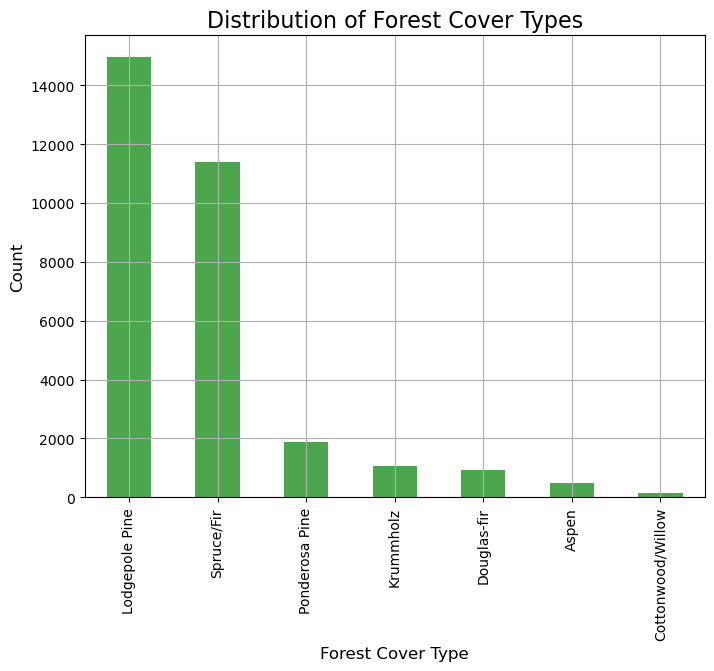

In [162]:
plt.figure(figsize=(8, 6))
df_cleaned['Forest_Cover'].value_counts().plot(kind='bar', color='green', alpha=0.7)
plt.grid(True)
plt.title('Distribution of Forest Cover Types', fontsize=16)
plt.xlabel('Forest Cover Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

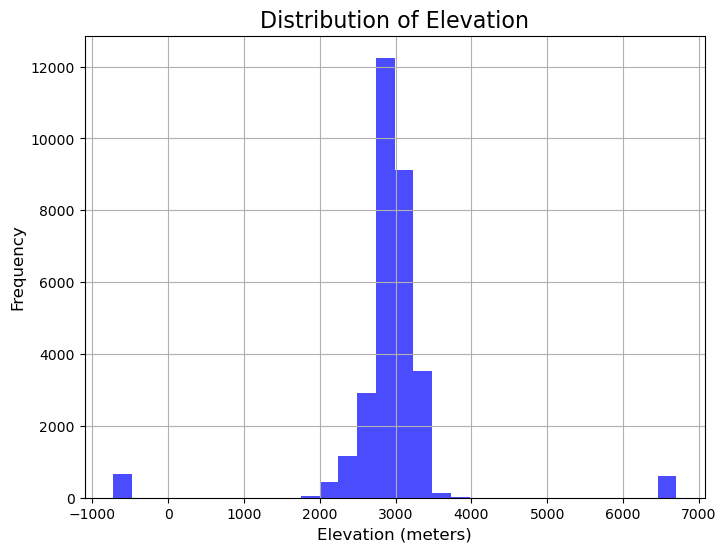

In [160]:
plt.figure(figsize=(8, 6))
df_cleaned['Elevation'].hist(bins=30, color='blue', alpha=0.7)
plt.title('Distribution of Elevation', fontsize=16)
plt.xlabel('Elevation (meters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()